In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Load Data
cols = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

def load_data(path: str) -> pd.DataFrame:
    return pd.read_csv(
        path, sep=' +', header=None,
        usecols=range(26), names=cols, engine='python'
    )

train = load_data('../Dataset/train_FD001.txt')
test  = load_data('../Dataset/test_FD001.txt')
rul   = pd.read_csv('../Dataset/RUL_FD001.txt', header=None, names=['rul'])

In [3]:
train.head()

,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   os1     20631 non-null  float64
 3   os2     20631 non-null  float64
 4   os3     20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int64  
 22  s18     2

In [5]:
#Droping unimportant features based on EDA and domain knowledge
DROP_SENSORS = ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']
DROP_SETTINGS = ['os3']  # single value in FD001/FD003; keep for FD002/FD004

KEEP_SENSORS = ['s2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']

train.drop(columns=DROP_SENSORS + DROP_SETTINGS, inplace=True)
test.drop(columns=DROP_SENSORS + DROP_SETTINGS, inplace=True)

In [6]:
#compute RUL for training data
def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['RUL'] = max_cycle - df['cycle']
    return df

train = add_rul(train)

In [7]:
#For the test set, RUL at the last cycle
last_cycles = test.groupby('unit')['cycle'].max().reset_index()
last_cycles['RUL'] = rul['rul'].values
test = test.merge(last_cycles[['unit', 'RUL']], on='unit', how='left')
# Keep only the last cycle row per engine for evaluation
test_last = test.groupby('unit').last().reset_index()

In [8]:
#Rul clipping to handle outliers and focus on near-term predictions
RUL_CLIP = 125  # standard choice for C-MAPSS; tune per dataset

train['RUL'] = train['RUL'].clip(upper=RUL_CLIP)

In [9]:
#normalization 
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train[KEEP_SENSORS] = scaler.fit_transform(train[KEEP_SENSORS])
test[KEEP_SENSORS]  = scaler.transform(test[KEEP_SENSORS])

In [10]:
def add_rolling_features(df: pd.DataFrame, windows: list[int] = [10, 20, 30]) -> pd.DataFrame:
    df = df.sort_values(['unit', 'cycle'])
    for w in windows:
        for s in KEEP_SENSORS:
            grp = df.groupby('unit')[s]
            df[f'{s}_mean_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=1).mean())
            df[f'{s}_std_{w}']  = grp.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
    return df

train = add_rolling_features(train)
test  = add_rolling_features(test)
test_last = test.groupby('unit').last().reset_index()

In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(train, groups=train['unit']))

df_train = train.iloc[train_idx]
df_val   = train.iloc[val_idx]

In [ ]:
import xgboost as xgb

FEATURE_COLS = [c for c in train.columns if c not in ['unit', 'cycle', 'RUL']]

X_train = df_train[FEATURE_COLS].values
y_train = df_train['RUL'].values

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

preds = model.predict(df_val[FEATURE_COLS].values)

rmse = np.sqrt(mean_squared_error(df_val['RUL'], preds))
mae = mean_absolute_error(df_val['RUL'], preds)

print(f"Validation RMSE: {rmse:.2f}")
print(f"Validation MAE: {mae:.2f}")

Validation RMSE: 14.21
Validation MAE: 10.20


In [14]:
X_test = test_last[FEATURE_COLS]
y_test = test_last['RUL']

test_preds = model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
print(f"Test RMSE: {rmse_test:.2f}")

Test RMSE: 17.48


In [15]:
results = pd.DataFrame({
    'unit': test_last['unit'],
    'true_RUL': y_test,
    'pred_RUL': test_preds
})

results.head(10)

,unit,true_RUL,pred_RUL
0,1,112,120.121605
1,2,98,115.934517
2,3,69,57.182632
3,4,82,97.767319
4,5,91,81.511154
5,6,93,122.767960
6,7,91,94.499672
7,8,95,113.684662
8,9,111,125.661850
9,10,96,88.581238


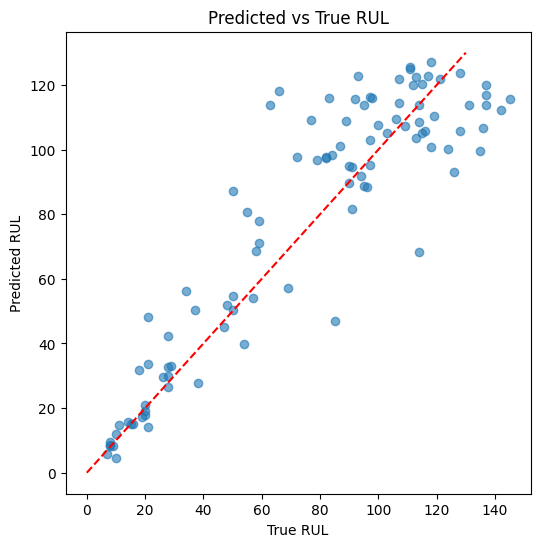

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(results['true_RUL'], results['pred_RUL'], alpha=0.6)
plt.plot([0, 130], [0, 130], 'r--')  # ideal line
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.show()

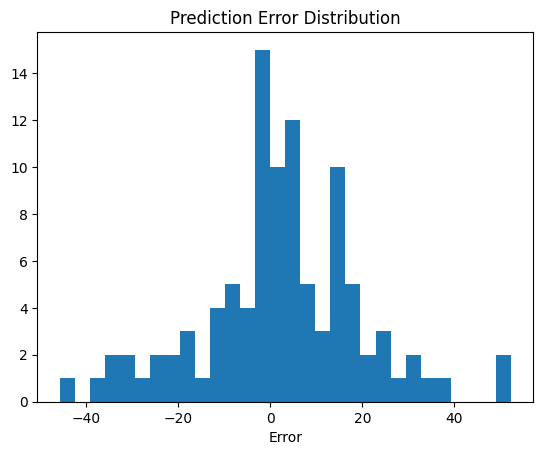

In [17]:
results['error'] = results['pred_RUL'] - results['true_RUL']

plt.hist(results['error'], bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

In [18]:
results['abs_error'] = results['error'].abs()

worst = results.sort_values(by='abs_error', ascending=False).head(10)
worst

,unit,true_RUL,pred_RUL,error,abs_error
26,27,66,118.261078,52.261078,52.261078
78,79,63,113.857391,50.857391,50.857391
44,45,114,68.272163,-45.727837,45.727837
92,93,85,47.015453,-37.984547,37.984547
71,72,50,87.244186,37.244186,37.244186
46,47,135,99.710274,-35.289726,35.289726
73,74,126,93.037346,-32.962654,32.962654
14,15,83,115.921127,32.921127,32.921127
66,67,77,109.175964,32.175964,32.175964
5,6,93,122.767960,29.767960,29.767960


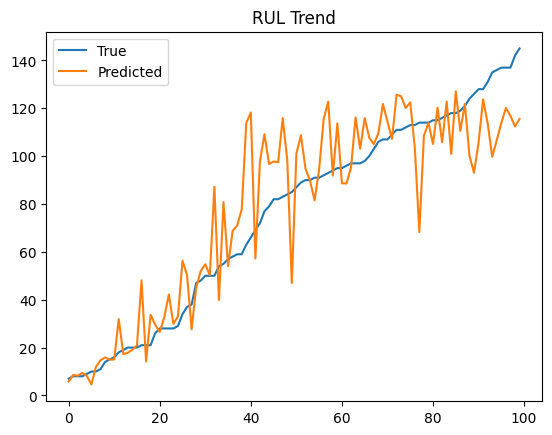

In [19]:
results_sorted = results.sort_values(by='true_RUL')

plt.plot(results_sorted['true_RUL'].values, label='True')
plt.plot(results_sorted['pred_RUL'].values, label='Predicted')
plt.legend()
plt.title("RUL Trend")
plt.show()

In [20]:
results['critical_true'] = results['true_RUL'] < 30
results['critical_pred'] = results['pred_RUL'] < 30

from sklearn.metrics import confusion_matrix

confusion_matrix(results['critical_true'], results['critical_pred'])

array([[74,  1],
       [ 6, 19]])